In [6]:
import sys
import os
import numpy as np
from sympy.abc import s
import matplotlib.pyplot as plt
from numpy.linalg import pinv as inversa


sys.path.insert(0, os.path.abspath(".."))

import src.Shaper_ATLAS_Simulator as Shaper_ATLAS_Simulator

# Simulação de Sinais

In [7]:
# Função sinal leitura (saida shaper) #


def saida_shaper(lista: list | np.ndarray, matriz):
    """
    Saida esperada:

    entrada:
    lista = np.array([1, 2, 3, 4])
    matriz = np.array(
        [[11, 12, 13, 14], [15, 16, 17, 18], [19, 20, 21, 22], [23, 24, 25, 26]]
        )

    saida:
    resultado1 = array( # a11 da lista x linha 1 da matriz. a12 da lista vezes linha 3 da matriz deslocado
        [[11, 12, 13, 14],
        [ 0, 30, 32, 34],
        [ 0,  0, 57, 60],
        [ 0,  0,  0, 92]
        ])

    resultado2 = array([ 11,  42, 102, 200])) # soma das colunas
    """

    # n_linhas, n_cols = np.array(matriz).shape
    n_linhas = len(matriz)
    n_cols = len(matriz[0])

    # resultado1: matriz deslocada e multiplicada
    resultado1 = np.zeros((n_linhas, n_cols))
    for linha in range(n_linhas):
        for cols in range(n_cols - linha):
            resultado1[linha][linha + cols] = lista[linha] * matriz[linha][cols]

    resultado1 = np.array(resultado1)

    # resultado2: soma por coluna
    resultado2 = resultado1.sum(axis=0)

    return resultado1, resultado2


# Teste #
lista = np.array([1, 2, 3, 4])
matriz = np.array(
    [[11, 12, 13, 14], [15, 16, 17, 18], [19, 20, 21, 22], [23, 24, 25, 26]]
)
# r1, r2 = saida_shaper(lista=np.flipud(lista), matriz=matriz)
# r1, r2

In [8]:
# N = 500  # quantidade de amostras da leitura
qntd_amostras_leitura = 50
media_energia_cada_cintilador = 30

sinal_original = np.zeros(qntd_amostras_leitura)

# aquela imagem, q TMQ passou e tava na apresentaçao pro michel, a primeira parte #
# sortear indices de sinal_original
# qntd de sorteios = 20 a 30 % de qntd_amostras_leitura

# a primeira parte (as posições)
qntd_posicoes = int(0.2 * qntd_amostras_leitura)
indx = np.random.permutation(len(sinal_original))[:qntd_posicoes]
# aquela imagem, q TMQ passou e tava na apresentaçao pro michel, a segunda parte #
# for i in indx:
#     sinal_original[i] = int(np.random.exponential(media_energia_cada_cintilador))

sinal_original[indx] = np.random.exponential(
    media_energia_cada_cintilador, size=len(indx)
).astype(int)

# Sinal original com as posiçoes (indx) e as qntds de energia (valor em si)
# A segunda parte (as posições com as devidas energias)
# sinal_original[0:10],
sinal_original.shape

(50,)

In [9]:
# Gerando Formas de onda em diversos cenários #

# Erro de cada elemento do circuito
error = (  # dois ultimos são tau1 e tau2
    np.array([10, 1, 1, 1, 2, 2, 2, 0.10, 0, 0], dtype=float)
) / 100

# Parametros do CKT Shaper ATLAS#
trasnfer_function, component, component_values = Shaper_ATLAS_Simulator.ckt_parameters()

# Gerador de forma de onda #
parametros_MC = {
    "iterations": qntd_amostras_leitura,
    "t": np.arange(0, qntd_amostras_leitura) * 25 * 10**-9,
    "FT": trasnfer_function,  # literal
    "erro": error,
    "components": component,
    "nominal_values": component_values,
}

*_, wave_former = Shaper_ATLAS_Simulator.MonteCarlo_iteration(**parametros_MC)
wave_former = np.array(wave_former)

# Formas de onda diversas #
# wave_former[:2]  # matriz N x N
np.array(wave_former).shape

(50, 50)

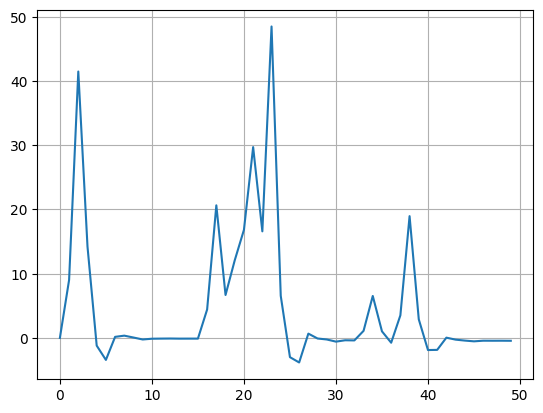

In [10]:
# Saída Shaper #

resultados, readout_shaper = saida_shaper(matriz=wave_former, lista=sinal_original)
# sinal_original = trem de impulsos # energy truth (sinal de enregia verdadeiro)


plt.plot(readout_shaper)
plt.grid()
# plt.xlim(0, 25)

In [11]:
# Função da matriz de observação #


def matriz_observacao(x: list | np.ndarray, ordem_filtro: int = 2):
    return np.lib.stride_tricks.sliding_window_view(np.array(x), ordem_filtro)


# matriz_observacao(np.array([1, 2, 3, 4]), ordem_filtro=3)

# FILTRO LS

daqui pra baixo eh o filtro 

In [12]:
# matriz obs
ordem_filtro = 7  # indicação TMQ
matriz_obs = matriz_observacao(readout_shaper, ordem_filtro=ordem_filtro)
matriz_obs[5]

array([-3.42612983,  0.16539682,  0.35348648,  0.06083172, -0.24366187,
       -0.12622735, -0.10615371])

In [13]:
# Calculo pesomatriz_obs.T @ matriz_obs
aux_w = inversa(matriz_obs.T @ matriz_obs) @ matriz_obs.T
# aux_w[0]

In [14]:
limite_filtro = qntd_amostras_leitura - ordem_filtro + 3
w = aux_w @ sinal_original[2:limite_filtro]
# formato_esperado_w = lista com sete itens sendo o do meio com maior amplitude
w = np.flipud(w)
w.shape, w

((7,),
 array([ 0.07176542, -0.28803132,  1.11223244, -0.22533148,  0.07186293,
         0.07357866, -0.0347939 ]))

In [15]:
# Sinal Estimado #

sinal_recuperado = np.zeros(len(readout_shaper))

tamanho = len(readout_shaper) - ordem_filtro + 1
for i in range(len(readout_shaper) - ordem_filtro + 1):

    # sinal_recuperado = matriz_obs @ w
    if i + ordem_filtro >= len(readout_shaper):
        break
    sinal_recuperado[i] = sum(readout_shaper[i : i + ordem_filtro] * w)

# sinal_recuperado = [readout_shaper[i : i + ordem_filtro] * w for i in range(tamanho)]

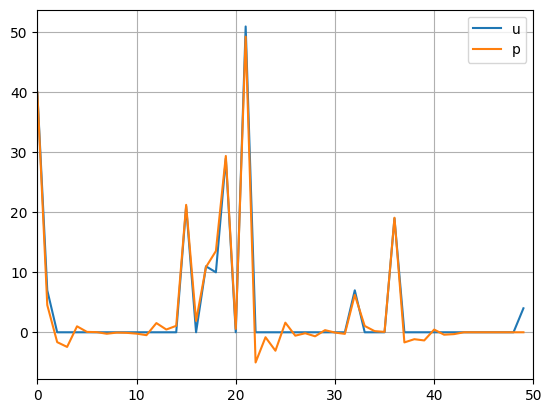

In [ ]:
plt.plot(sinal_original, label="Original")
plt.plot(sinal_recuperado, label="Estimado")
plt.legend("upper")
# plt.figsize =
plt.xlim(0, 50)
# plt.ylim(0, 2.5 * 10**17)
plt.grid()
plt.show()

Se preocupar com o estimado estar abaixo do zero (mudar ordem do filtro)

Fazer RMSE por ordem do filtro


In [17]:
A = sinal_original
B = sinal_recuperado
erro_abs_medio = np.mean(np.abs(A - B))  # MAE - mean absolute error
rmse = np.sqrt(np.mean((A - B) ** 2))  # RMSE - root mean squared error

# Testes

In [5]:
# Funções auxiliares #
def saida_shaper(lista: list | np.ndarray, matriz):
    """
    Saida esperada:

    entrada:
    lista = np.array([1, 2, 3, 4])
    matriz = np.array(
        [[11, 12, 13, 14], [15, 16, 17, 18], [19, 20, 21, 22], [23, 24, 25, 26]]
        )

    saida:
    resultado1 = array( # a11 da lista x linha 1 da matriz. a12 da lista vezes linha 3 da matriz deslocado
        [[11, 12, 13, 14],
        [ 0, 30, 32, 34],
        [ 0,  0, 57, 60],
        [ 0,  0,  0, 92]
        ])

    resultado2 = array([ 11,  42, 102, 200])) # soma das colunas
    """

    # n_linhas, n_cols = np.array(matriz).shape
    n_linhas = len(matriz)
    n_cols = len(matriz[0])

    # resultado1: matriz deslocada e multiplicada
    resultado1 = np.zeros((n_linhas, n_cols))
    for linha in range(n_linhas):
        for cols in range(n_cols - linha):
            resultado1[linha][linha + cols] = lista[linha] * matriz[linha][cols]

    resultado1 = np.array(resultado1)

    # resultado2: soma por coluna
    resultado2 = resultado1.sum(axis=0)

    return resultado1, resultado2


def matriz_observacao(x: list | np.ndarray, ordem_filtro: int = 7):
    return np.lib.stride_tricks.sliding_window_view(np.array(x), ordem_filtro)


# Comparação numerica
def RMSE_e_MAE_por_ordem(A, B, printar: bool = False):
    """
    A: sinal original
    B: sinal obtido
    """
    diff = A - B
    erro_abs_medio = np.mean(np.abs(diff))  # MAE - mean absolute error
    rmse = np.sqrt(np.mean(diff**2))  # RMSE - root mean squared error

    if printar:
        print(f"{erro_abs_medio = :.4f}")
        print(f"{rmse = :.4f}")

    return rmse, erro_abs_medio


def subplots_todos_sinais(original, readout, estimado):
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

    ax1 = fig.add_subplot(gs[0, 0])  # topo esquerdo
    ax2 = fig.add_subplot(gs[0, 1])  # topo direito
    ax3 = fig.add_subplot(gs[1, 0])  # embaixo esquerdo
    ax4 = fig.add_subplot(gs[1, 1])  # embaixo direito

    # Topo esquerdo: original
    ax1.plot(original, color="tab:blue")
    ax1.set_title("Sinal Original")
    ax1.set_xlabel("Amostra")
    ax1.set_ylabel("Amplitude")
    ax1.grid()

    # Topo direito: readout
    ax2.plot(readout, color="tab:orange")
    ax2.set_title("Readout")
    ax2.set_xlabel("Amostra")
    ax2.grid()

    readout1 = np.clip(readout, 0, None)

    # Embaixo esquerdo: readout_shaper clipado
    ax3.plot(readout1, color="tab:green")
    ax3.set_title("Readout clipado")
    ax3.set_xlabel("Amostra")
    ax3.set_ylabel("Amplitude")
    ax3.grid()

    # Embaixo direito: sinal recuperado
    ax4.plot(estimado, color="tab:red")
    ax4.set_title("Sinal Estimado")
    ax4.set_xlabel("Amostra")
    ax4.set_ylabel("Amplitude")
    ax4.grid()

    plt.tight_layout()
    plt.show()


#

In [ ]:
# Sinal orignal #
qntd_amostras_leitura = 75
media_energia_cada_cintilador = 30

sinal_original = np.zeros(qntd_amostras_leitura)
qntd_posicoes = int(0.2 * qntd_amostras_leitura)
indx = np.random.permutation(len(sinal_original))[:qntd_posicoes]

# gerando simulaçao do sinal original
sinal_original[indx] = np.random.exponential(
    media_energia_cada_cintilador, size=len(indx)
).astype(int)

# Erro de cada elemento do circuito
circuito_error = (  # dois ultimos são tau1 e tau2
    np.array([10, 1, 1, 1, 2, 2, 2, 0.10, 0, 0], dtype=float)
) / 100

# Parametros do CKT Shaper ATLAS#
trasnfer_function, component, component_values = Shaper_ATLAS_Simulator.ckt_parameters()

# Gerador de forma de onda #
parametros_MC = {
    "iterations": qntd_amostras_leitura,
    "t": np.arange(0, qntd_amostras_leitura) * 25 * 10**-9,
    "FT": trasnfer_function,  # literal
    "erro": circuito_error,
    "components": component,
    "nominal_values": component_values,
}

*_, wave_former = Shaper_ATLAS_Simulator.MonteCarlo_iteration(**parametros_MC)
wave_former = np.array(wave_former)

# Saída Shaper #
_, readout_shaper0 = saida_shaper(matriz=wave_former, lista=sinal_original)

readout_clipado = np.clip(readout_shaper0, 0, None)

ckt_parameters
Monte Carlo iteration


Filtro:

In [ ]:
# Filtro antigo #


def filtro_LS(
    readout_shaper: np.ndarray,
    sinal_desejado: np.ndarray,
    ordem_filter: int = 7,
):
    """
    Filtro LS para deconvolução do Circuioto Shaper com o sinal de entrada.
    Método: Pseudo Inversa de Moore-Penrose
    """
    # Matriz de Observação #
    matriz_obs = matriz_observacao(readout_shaper, ordem_filtro=ordem_filter)

    # Calculo peso #
    # limite_filtro = qntd_amostras - ordem_filter + 3
    limite_filtro = len(readout_shaper) - ordem_filter + 3

    aux_peso = inversa(matriz_obs.T @ matriz_obs) @ matriz_obs.T
    peso = np.flipud(aux_peso @ sinal_desejado[2:limite_filtro])

    # Sinal Estimado/Recuperado #
    sinal_estimado = np.zeros(len(readout_shaper))

    for i in range(len(readout_shaper) - ordem_filter + 1):
        sinal_estimado[i] = np.sum(readout_shaper[i : i + ordem_filter] * peso)

    plt.plot(sinal_original, label="Original")
    plt.plot(sinal_estimado, label="Estimado")

    plt.axvline(  # linha vermelha vertical #
        x=limite_filtro,  # posição no eixo x
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="limite_filtro",
    )

    plt.legend(["Original", "Estimado", "Limite da estimativa"], loc="upper right")
    plt.title("Antigo")

    plt.grid()
    plt.show()

    return sinal_estimado


#############################


def filtro_LS_novo_novo(
    sinal_original,
    readout_shaper,
):
    # +/- Constantes #
    ordem_filtro = 7
    delay = 2
    # limite_filtro = len(readout_shaper) - ordem_filtro + 3
    limite_filtro = len(readout_shaper) - ordem_filtro + 1 + delay

    # matriz obs
    matriz_obs = matriz_observacao(readout_shaper, ordem_filtro=ordem_filtro)

    # Pesos #
    aux_w = inversa(matriz_obs.T @ matriz_obs) @ matriz_obs.T
    w = aux_w @ sinal_original[delay:limite_filtro]
    w = np.flipud(w)

    sinal_recuperado_zerado = np.zeros(len(readout_shaper))
    sinal_recuperado2 = sinal_recuperado_zerado

    len_signal_rec = len(readout_shaper) - ordem_filtro + 1

    for i in range(len_signal_rec):
        sinal_recuperado2[i] = sum(readout_shaper[i : i + ordem_filtro] * w)

    sinal_recuperado2 = np.clip(sinal_recuperado2, 0, None)

    plt.plot(sinal_original, label="Original")
    plt.plot(sinal_recuperado2, label="Estimado")

    plt.axvline(  # linha vermelha vertical #
        x=limite_filtro,  # posição no eixo x
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="limite_filtro",
    )

    plt.legend(["Original", "Estimado", "Limite da estimativa"], loc="upper right")
    plt.title("Novo")

    plt.grid()
    plt.show()
    return sinal_recuperado2


#

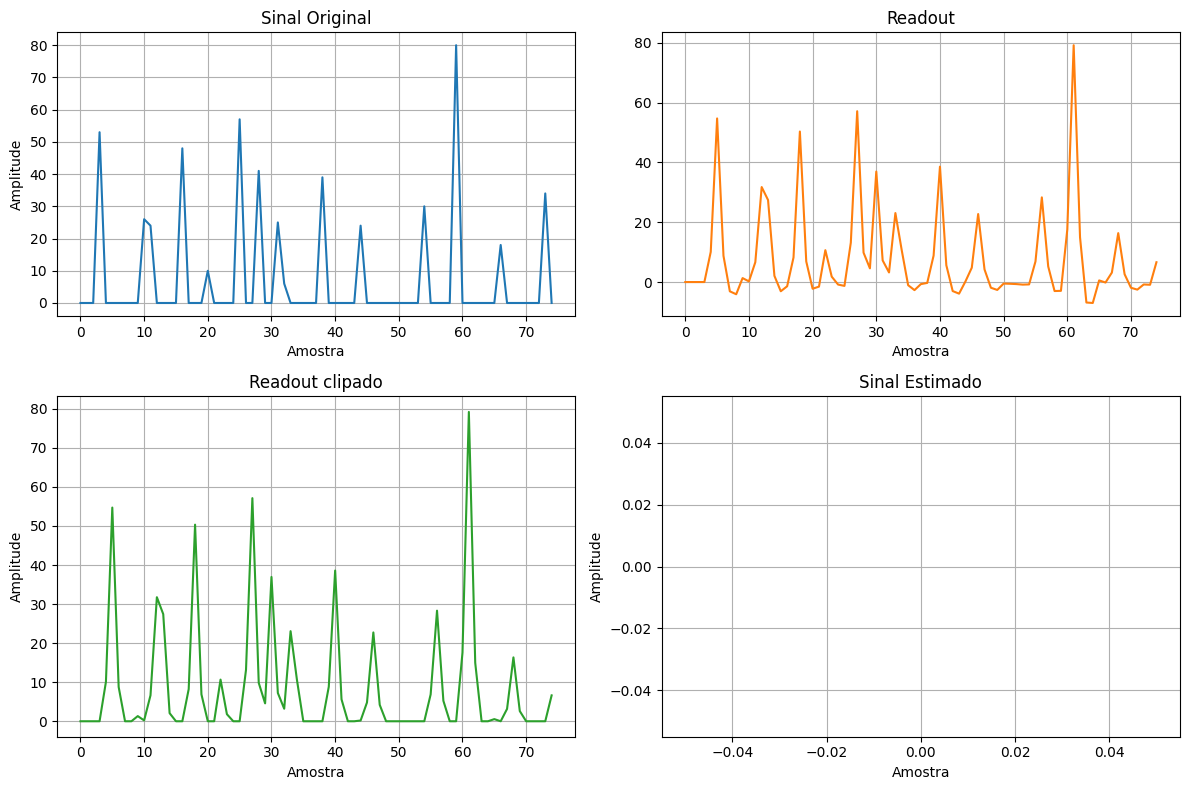

In [9]:
# Readout com clip x sem clip #
subplots_todos_sinais(sinal_original, readout_shaper0, 0)

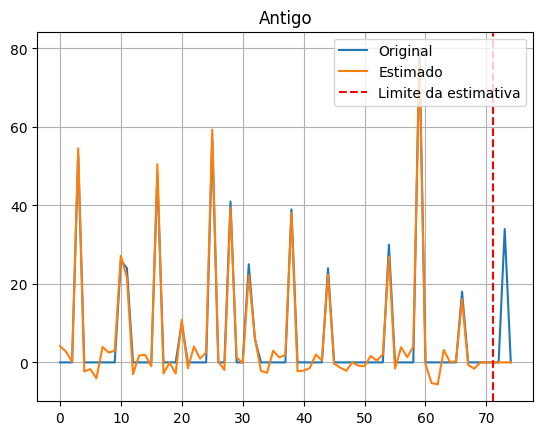

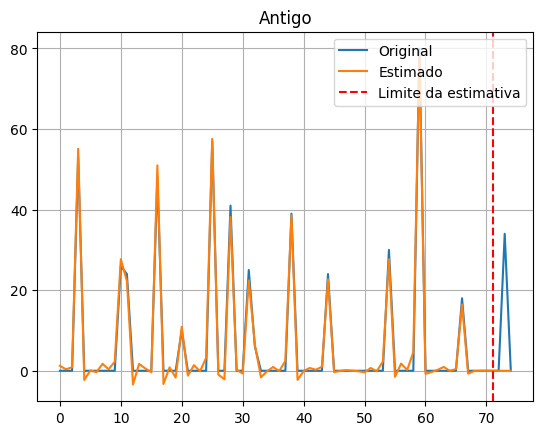

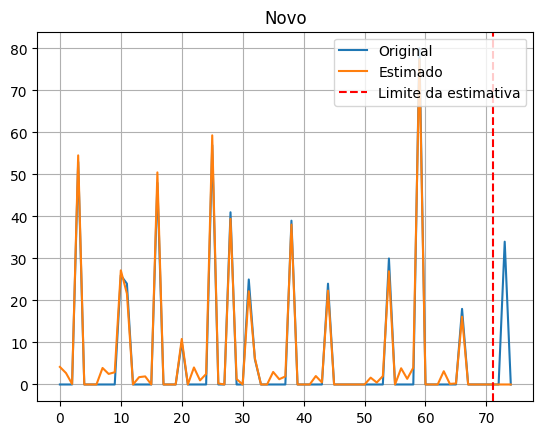

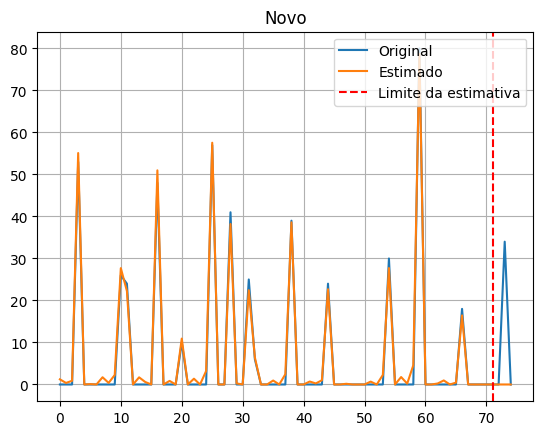

In [14]:
s_rec0 = filtro_LS(
    sinal_desejado=sinal_original,
    readout_shaper=readout_shaper0,
)

s_rec1 = filtro_LS(
    sinal_desejado=sinal_original,
    readout_shaper=readout_clipado,
)

s_rec2 = filtro_LS_novo_novo(
    sinal_original=sinal_original,
    readout_shaper=readout_shaper0,
)

s_rec3 = filtro_LS_novo_novo(
    sinal_original=sinal_original,
    readout_shaper=readout_clipado,
)

rmse0, erro_abs_medio0 = RMSE_e_MAE_por_ordem(s_rec0, sinal_original)
rmse1, erro_abs_medio1 = RMSE_e_MAE_por_ordem(s_rec1, sinal_original)
rmse2, erro_abs_medio2 = RMSE_e_MAE_por_ordem(s_rec2, sinal_original)
rmse3, erro_abs_medio3 = RMSE_e_MAE_por_ordem(s_rec3, sinal_original)

In [ ]:
def print_resultado(
    rmse0,
    erro_abs_medio0,
    rmse1,
    erro_abs_medio1,
    rmse2,
    erro_abs_medio2,
    rmse3,
    erro_abs_medio3,
):
    print(f"filtro_LS normal: {rmse0 = :.2f}, {erro_abs_medio0 = :.2f}")
    print(f"filtro_LS clipado: {rmse1 = :.2f}, {erro_abs_medio1 = :.2f}\n")
    print(f"filtro_LS_novo normal: {rmse2 = :.2f}, {erro_abs_medio2 = :.2f}")
    print(f"filtro_LS_novo clipado : {rmse3 = :.2f}, {erro_abs_medio3 = :.2f}\n\n")

    delta_rmse01 = rmse0 - rmse1
    delta_mae01 = erro_abs_medio0 - erro_abs_medio1

    delta_rmse02 = rmse0 - rmse2
    delta_mae02 = erro_abs_medio0 - erro_abs_medio2

    delta_rmse03 = rmse0 - rmse3
    delta_mae03 = erro_abs_medio0 - erro_abs_medio3
    ##
    delta_rmse12 = rmse1 - rmse2
    delta_mae12 = erro_abs_medio1 - erro_abs_medio2

    delta_rmse13 = rmse1 - rmse3
    delta_mae13 = erro_abs_medio1 - erro_abs_medio3
    ##
    delta_rmse23 = rmse2 - rmse3
    delta_mae23 = erro_abs_medio2 - erro_abs_medio3

    print(f"{delta_rmse01 = :.2f}, {delta_mae01 = :.2f}")
    print(f"{delta_rmse02 = :.2f}, {delta_mae02 = :.2f}")
    print(f"{delta_rmse03 = :.2f}, {delta_mae03 = :.2f}")
    print(f"{delta_rmse12 = :.2f}, {delta_mae12 = :.2f}")
    print(f"{delta_rmse13 = :.2f}, {delta_mae13 = :.2f}")
    print(f"{delta_rmse23 = :.2f}, {delta_mae23 = :.2f}")


print_resultado(
    rmse0,
    erro_abs_medio0,
    rmse1,
    erro_abs_medio1,
    rmse2,
    erro_abs_medio2,
    rmse3,
    erro_abs_medio3,
)

filtro_LS normal: rmse0 = 4.50, erro_abs_medio0 = 2.22
filtro_LS clipado: rmse1 = 4.19, erro_abs_medio1 = 1.51

filtro_LS_novo normal: rmse2 = 4.27, erro_abs_medio2 = 1.52
filtro_LS_novo clipado : rmse3 = 4.11, erro_abs_medio3 = 1.18


delta_rmse01 = 0.31, delta_mae01 = 0.71
delta_rmse02 = 0.23, delta_mae02 = 0.71
delta_rmse03 = 0.39, delta_mae03 = 1.05
delta_rmse12 = -0.08, delta_mae12 = -0.01
delta_rmse13 = 0.08, delta_mae13 = 0.33
delta_rmse23 = 0.16, delta_mae23 = 0.34


In [ ]:
# Com zero padding
# sinal_recuperado2 = sinal_recuperado_zerado
# s = sinal_recuperado_zerado

# Zero padding no final
readout_pad = np.concatenate([np.zeros(2), readout_shaper])


len_signal_rec = len(readout_shaper)  # - ordem_filtro + 1

for i in range(len_signal_rec):
    sinal_recuperado2[i] = sum(readout_pad[i : i + ordem_filtro] * w)

sinal_recuperado2 = np.clip(sinal_recuperado2, 0, None)

plt.plot(sinal_original, label="Original")
plt.plot(sinal_recuperado2, label="Estimado")

plt.axvline(  # linha vermelha vertical #
    x=limite_filtro,  # posição no eixo x
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="limite_filtro",
)


plt.legend(["Original", "Estimado", "Limite da estimativa"], loc="upper right")
# plt.xlim(40, 50)
plt.grid()
plt.show()

In [61]:
def ruidez(sinal_original, sinal_obtido):
    ruido = sinal_obtido - sinal_original
    plt.plot(ruido, label="Ruido")
    plt.legend(loc="lower left")
    plt.xlim(0, limite_filtro + 1)
    # plt.ylim(-10, 10)
    plt.grid()
    plt.show()
    return ruido

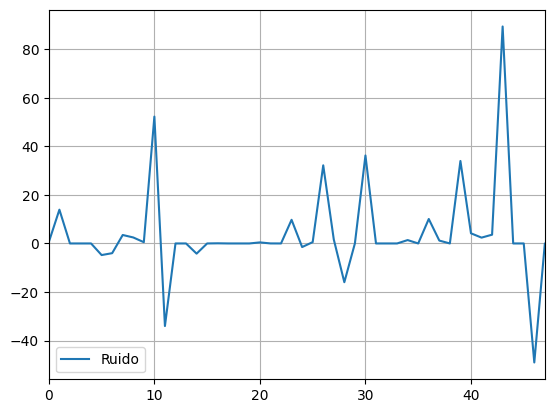

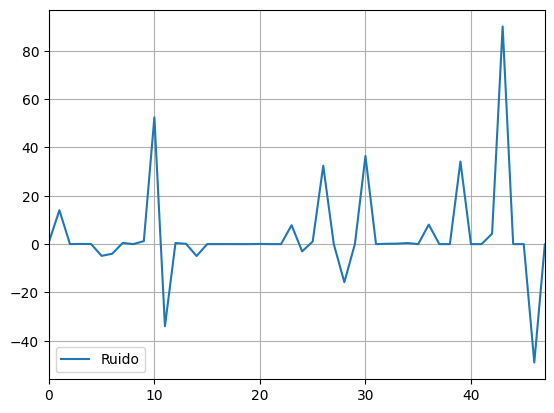

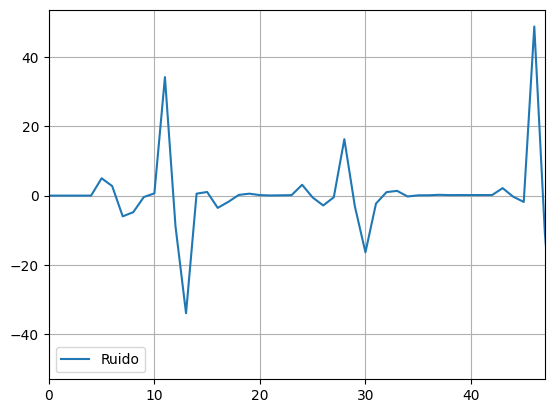

In [ ]:
r1 = ruidez(sinal_original, s_rec1)
r2 = ruidez(sinal_original, s_rec2)
ruido_readout = ruidez(readout_shaper0, sinal_original)

In [ ]:
import pandas as pd

ruido1 = pd.DataFrame(r1[:limite_filtro])
ruido1.describe()

,0
count,46.000000
mean,0.533344
std,1.653118
min,-2.680891
25%,0.000000
50%,0.000000
75%,0.425930
max,7.172007


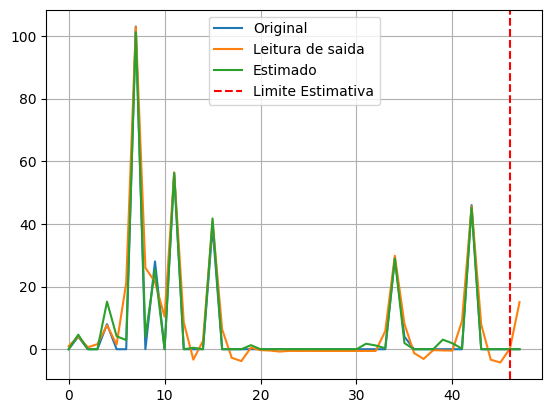

In [27]:
def plot_3_sinas(original, readout, recuperado, limite_estimativa):
    corr = np.correlate(original, readout, mode="full")
    lags = np.arange(-len(readout) + 1, len(original))
    delay_sinais = lags[np.argmax(corr)]

    readout_alinhado = readout[-delay_sinais:]
    original_alinhado = original[: len(readout_alinhado)]
    estimado_alinhado = recuperado[: len(readout_alinhado)]

    plt.plot(original_alinhado, label="Original")
    plt.plot(readout_alinhado, label="Leitura de saida")
    plt.plot(estimado_alinhado, label="Estimado")

    plt.axvline(
        x=limite_estimativa,  # posição no eixo x
        color="red",
        linestyle="--",
        linewidth=1.5,
        # label="limite_filtro"
    )

    plt.legend(["Original", "Leitura de saida", "Estimado", "Limite Estimativa"])
    # plt.xlim(40, 50)
    plt.grid()
    plt.show()


plot_3_sinas(sinal_original, readout_shaper, sinal_recuperado2, limite_filtro)

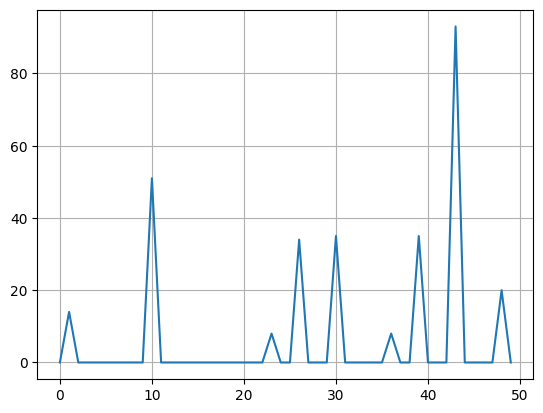

In [51]:
plt.plot(sinal_original)
plt.grid()

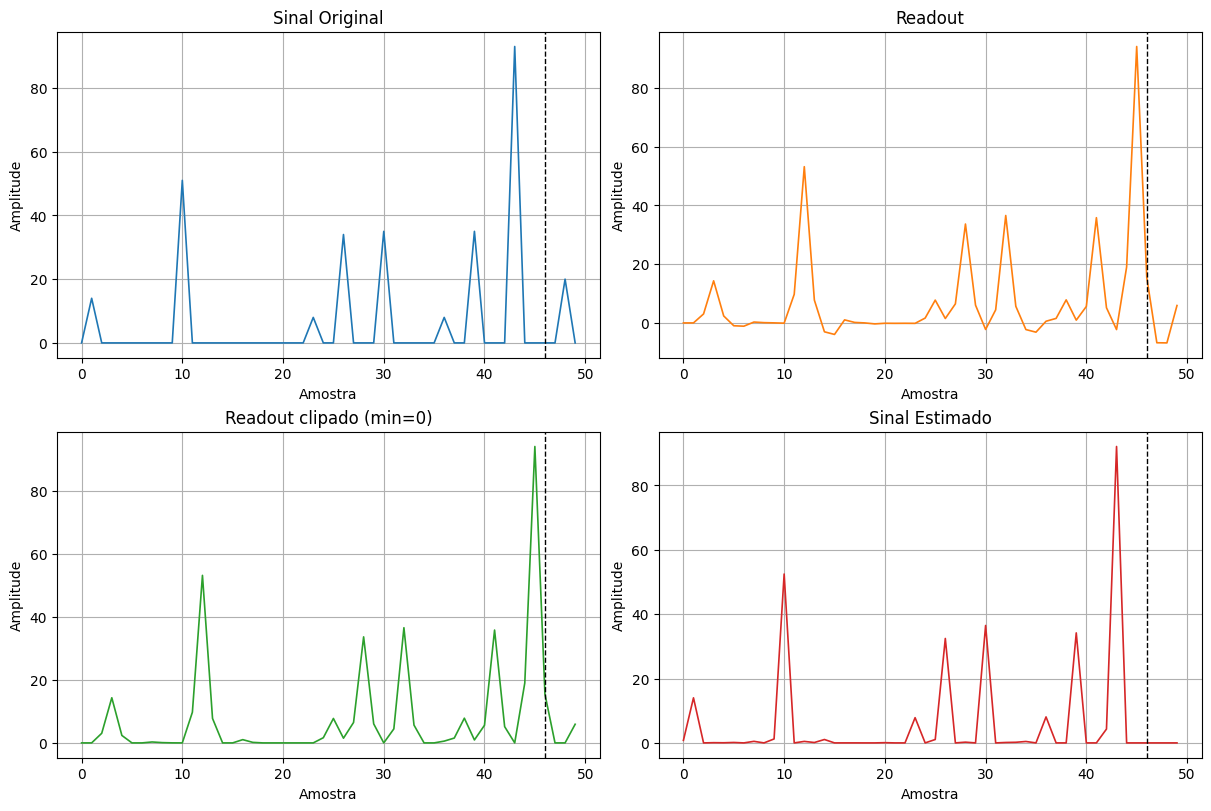

In [46]:
# Plot de todos os sinais gerado #
def subplots_todos_sinais(
    original,
    readout,
    estimado,
    limite_filtro=None,
    clip_min=0.0,
    figsize=(12, 8),
):
    original = np.asarray(original)
    readout = np.asarray(readout)
    estimado = np.asarray(estimado)
    readout_clipado = np.clip(readout, clip_min, None)

    fig, axs = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)

    configs = [
        (axs[0, 0], original, "Sinal Original", "tab:blue"),
        (axs[0, 1], readout, "Readout", "tab:orange"),
        (
            axs[1, 0],
            readout_clipado,
            f"Readout clipado (min={clip_min:g})",
            "tab:green",
        ),
        (axs[1, 1], estimado, "Sinal Estimado", "tab:red"),
    ]

    for ax, y, title, color in configs:
        ax.plot(y, color=color, linewidth=1.2)
        ax.set_title(title)
        ax.set_xlabel("Amostra")
        ax.set_ylabel("Amplitude")
        ax.grid()

        if limite_filtro is not None:
            ax.axvline(limite_filtro, color="black", linestyle="--", linewidth=1.0)

    return fig, axs


fig, axs = subplots_todos_sinais(
    sinal_original, readout_shaper0, s_rec2, limite_filtro=limite_filtro
)
plt.show()